# Taller de movilidad urbana: taxis y clima en Nueva York

**Caso de estudio:** viajes de NYC TLC Yellow Taxi durante enero de 2024.

En este taller construiremos un flujo reproducible: adquisición, inspección, auditoría de calidad, enriquecimiento por zonas, agregación temporal, integración con clima y análisis exploratorio. No buscamos demostrar causalidad, sino aprender a formular y comprobar preguntas con datos reales.

## Objetivos

Al finalizar podrás:

- construir y validar una URL de datos abiertos;
- inspeccionar estructura, tipos y faltantes antes de analizar;
- convertir reglas de calidad en una tabla de auditoría;
- enriquecer viajes mediante uniones `many_to_one`;
- agregar pickups por zona y hora sin sesgar la serie temporal;
- convertir observaciones meteorológicas de UTC a `America/New_York`;
- comunicar patrones y límites de un análisis exploratorio.

> **Pregunta guía:** ¿cómo varían los pickups de Yellow Taxi por lugar y hora, y qué relación exploratoria muestran con temperatura y precipitación?

## Ficha de fuentes

| Fuente | Recurso usado | Papel en el taller |
|---|---|---|
| [NYC TLC Trip Record Data](https://www.nyc.gov/site/tlc/about/tlc-trip-record-data.page) | Yellow Taxi, enero de 2024 (`yellow_tripdata_2024-01.parquet`) | fecha/hora, zonas, distancia, pasajeros e importes de viajes reportados |
| NYC TLC | [Taxi Zone Lookup](https://d37ci6vzurychx.cloudfront.net/misc/taxi_zone_lookup.csv) | traduce `LocationID` a borough, zona y `service_zone` |
| NYC TLC | [Taxi Zone Shapefile](https://d37ci6vzurychx.cloudfront.net/misc/taxi_zones.zip) | geometrías para la extensión espacial opcional |
| [NOAA GHCNh](https://www.ncei.noaa.gov/products/global-historical-climatology-network-hourly) | estación `USW00094728`, año 2024 | observaciones de clima con marcas temporales UTC |

**Periodo común:** enero de 2024 en hora local de Nueva York. Los archivos se leen desde sus URL o desde un directorio temporal; este notebook no guarda datasets en el repositorio. Consulta la documentación y licencias de cada proveedor antes de reutilizar los datos.

## 1. Preparación y modo de ejecución

En Colab normalmente basta con ejecutar los imports. Si falta el motor Parquet, descomenta la instalación. La extensión espacial se instala solo si se desea ejecutar esa sección.

In [1]:
# Instalación opcional para Google Colab/Jupyter (descomentar si hace falta):
# %pip install -q pyarrow
# %pip install -q geopandas folium requests

from io import StringIO
import tempfile
from pathlib import Path
from urllib.request import urlopen

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

pd.set_option("display.max_columns", 50)
plt.style.use("seaborn-v0_8-whitegrid")

In [2]:
# True: primera semana de enero; False: todo enero. No hay muestreo aleatorio.
MODO_CLASE = False
INICIO_MES = pd.Timestamp("2024-01-01")
FIN_MES = pd.Timestamp("2024-02-01")
FIN_ANALISIS = pd.Timestamp("2024-01-08") if MODO_CLASE else FIN_MES
ZONA_HORARIA = "America/New_York"

print(f"Ventana: {INICIO_MES} hasta {FIN_ANALISIS} (fin no incluido)")

Ventana: 2024-01-01 00:00:00 hasta 2024-02-01 00:00:00 (fin no incluido)


`MODO_CLASE` limita la lectura mediante un filtro temporal de Parquet cuando el motor lo permite. La selección es una semana completa y determinista, no una muestra aleatoria: así preservamos horas consecutivas y el flujo de agregación. En modo completo, la misma lógica procesa todo enero.

## 2. URL validada y carga reproducible

In [3]:
def construir_url_tlc(tipo, anio, mes):
    """Construye una URL TLC válida para un tipo, año y mes."""
    prefijos = {
        "yellow": "yellow_tripdata",
        "green": "green_tripdata",
        "fhv": "fhv_tripdata",
        "fhvhv": "fhvhv_tripdata",
    }
    if tipo not in prefijos:
        opciones = ", ".join(prefijos)
        raise ValueError(f"tipo debe ser uno de: {opciones}")
    if isinstance(anio, bool) or not isinstance(anio, (int, np.integer)) or not 2009 <= anio <= 2100:
        raise ValueError("anio debe ser un entero entre 2009 y 2100")
    if isinstance(mes, bool) or not isinstance(mes, (int, np.integer)) or not 1 <= mes <= 12:
        raise ValueError("mes debe ser un entero entre 1 y 12")
    archivo = f"{prefijos[tipo]}_{anio}-{mes:02d}.parquet"
    return f"https://d37ci6vzurychx.cloudfront.net/trip-data/{archivo}"

URL_VIAJES = construir_url_tlc("yellow", 2024, 1)
URL_ZONAS = "https://d37ci6vzurychx.cloudfront.net/misc/taxi_zone_lookup.csv"
URL_GEOMETRIAS = "https://d37ci6vzurychx.cloudfront.net/misc/taxi_zones.zip"
URL_CLIMA = (
    "https://www.ncei.noaa.gov/oa/global-historical-climatology-network/"
    "hourly/access/by-year/2024/psv/GHCNh_USW00094728_2024.psv"
)
print(URL_VIAJES)

https://d37ci6vzurychx.cloudfront.net/trip-data/yellow_tripdata_2024-01.parquet


In [4]:
COLUMNAS_VIAJES = [
    "tpep_pickup_datetime", "tpep_dropoff_datetime",
    "passenger_count", "trip_distance", "PULocationID",
    "DOLocationID", "fare_amount", "total_amount",
]
filtros = [
    ("tpep_pickup_datetime", ">=", INICIO_MES.to_pydatetime()),
    ("tpep_pickup_datetime", "<", FIN_ANALISIS.to_pydatetime()),
]

# PyArrow aplica el filtro por fecha al leer los grupos de filas compatibles.
viajes_originales = pd.read_parquet(
    URL_VIAJES, columns=COLUMNAS_VIAJES, filters=filtros, engine="pyarrow"
)
print(f"Viajes cargados: {len(viajes_originales):,}")

Viajes cargados: 2,964,606


### Pregunta breve

¿Por qué una semana consecutiva es preferible a una muestra aleatoria si queremos comparar horas y días? Escribe una hipótesis antes de continuar.

<details><summary>Ver respuesta orientativa</summary>Una muestra aleatoria puede dejar horas incompletas y alterar sus conteos. Una ventana consecutiva conserva el orden, los ciclos diarios y el denominador temporal, aunque no necesariamente representa el mes completo.</details>

## 3. Inspección antes de limpiar

No debemos decidir reglas sin conocer el esquema. Observa dimensiones, ejemplos, tipos y faltantes.

In [5]:
print("Shape:", viajes_originales.shape)
display(viajes_originales.head())
print("\nInfo:")
viajes_originales.info()
print("\nTipos:")
display(viajes_originales.dtypes.rename("dtype").to_frame())

faltantes = (
    viajes_originales.isna().sum().rename("n_faltantes").to_frame()
    .assign(porcentaje=lambda x: 100 * x["n_faltantes"] / len(viajes_originales))
    .sort_values("porcentaje", ascending=False)
)
display(faltantes)

Shape: (2964606, 8)


,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,PULocationID,DOLocationID,fare_amount,total_amount
0,2024-01-01 00:57:55,2024-01-01 01:17:43,1.0,1.72,186,79,17.7,22.70
1,2024-01-01 00:03:00,2024-01-01 00:09:36,1.0,1.80,140,236,10.0,18.75
2,2024-01-01 00:17:06,2024-01-01 00:35:01,1.0,4.70,236,79,23.3,31.30
3,2024-01-01 00:36:38,2024-01-01 00:44:56,1.0,1.40,79,211,10.0,17.00
4,2024-01-01 00:46:51,2024-01-01 00:52:57,1.0,0.80,211,148,7.9,16.10



Info:
<class 'pandas.DataFrame'>
RangeIndex: 2964606 entries, 0 to 2964605
Data columns (total 8 columns):
 #   Column                 Dtype         
---  ------                 -----         
 0   tpep_pickup_datetime   datetime64[us]
 1   tpep_dropoff_datetime  datetime64[us]
 2   passenger_count        float64       
 3   trip_distance          float64       
 4   PULocationID           int32         
 5   DOLocationID           int32         
 6   fare_amount            float64       
 7   total_amount           float64       
dtypes: datetime64[us](2), float64(4), int32(2)
memory usage: 158.3 MB

Tipos:


,dtype
tpep_pickup_datetime,datetime64[us]
tpep_dropoff_datetime,datetime64[us]
passenger_count,float64
trip_distance,float64
PULocationID,int32
DOLocationID,int32
fare_amount,float64
total_amount,float64


,n_faltantes,porcentaje
passenger_count,140162,4.727846
tpep_pickup_datetime,0,0.000000
tpep_dropoff_datetime,0,0.000000
trip_distance,0,0.000000
PULocationID,0,0.000000
DOLocationID,0,0.000000
fare_amount,0,0.000000
total_amount,0,0.000000


**Observa:** `passenger_count` puede faltar por la forma de reporte. Su ausencia se conserva y no invalida automáticamente un viaje. Solo marcaremos como problemáticos los valores presentes fuera de un intervalo operativo razonable.

## 4. Calidad y auditoría

Las reglas siguientes son criterios analíticos, no verdades universales. Distancia máxima de 100 millas, hasta 8 pasajeros e importes menores a USD 1,000 son umbrales conservadores para detectar registros extremos o inválidos. Cada regla queda en una columna booleana.

In [6]:
calidad = viajes_originales.copy()
calidad["duracion_min"] = (
    calidad["tpep_dropoff_datetime"] - calidad["tpep_pickup_datetime"]
).dt.total_seconds() / 60

calidad["ok_pickup"] = calidad["tpep_pickup_datetime"].notna() & calidad["tpep_pickup_datetime"].between(INICIO_MES, FIN_ANALISIS, inclusive="left")
calidad["ok_dropoff"] = calidad["tpep_dropoff_datetime"].notna()
calidad["ok_duracion"] = calidad["duracion_min"].gt(0) & calidad["duracion_min"].le(24 * 60)
calidad["ok_distancia"] = calidad["trip_distance"].between(0, 100, inclusive="both")
calidad["ok_id_pickup_presente"] = calidad["PULocationID"].notna()
calidad["ok_id_dropoff_presente"] = calidad["DOLocationID"].notna()
calidad["ok_importes"] = (
    calidad["fare_amount"].between(0, 1_000, inclusive="both")
    & calidad["total_amount"].between(0, 1_000, inclusive="both")
    & calidad["total_amount"].ge(calidad["fare_amount"])
)
calidad["ok_pasajeros"] = calidad["passenger_count"].isna() | calidad["passenger_count"].between(0, 8, inclusive="both")

REGLAS = [c for c in calidad.columns if c.startswith("ok_")]
calidad["registro_valido"] = calidad[REGLAS].all(axis=1)
auditoria = pd.DataFrame({
    "regla": REGLAS,
    "cumplen": [int(calidad[c].sum()) for c in REGLAS],
    "incumplen": [int((~calidad[c]).sum()) for c in REGLAS],
})
auditoria["porcentaje_incumple"] = 100 * auditoria["incumplen"] / len(calidad)
display(auditoria.sort_values("porcentaje_incumple", ascending=False))

,regla,cumplen,incumplen,porcentaje_incumple
6,ok_importes,2927032,37574,1.267420
2,ok_duracion,2963720,886,0.029886
3,ok_distancia,2964547,59,0.001990
7,ok_pasajeros,2964605,1,0.000034
0,ok_pickup,2964606,0,0.000000
1,ok_dropoff,2964606,0,0.000000
5,ok_id_dropoff_presente,2964606,0,0.000000
4,ok_id_pickup_presente,2964606,0,0.000000


In [7]:
# Se mantienen por separado para no borrar silenciosamente información.
viajes_rechazados = calidad.loc[~calidad["registro_valido"]].copy()
viajes_validos = calidad.loc[calidad["registro_valido"]].copy()
print(f"Válidos: {len(viajes_validos):,} | Rechazados: {len(viajes_rechazados):,}")
display(viajes_rechazados[COLUMNAS_VIAJES + ["duracion_min"] + REGLAS].head())

Válidos: 2,926,101 | Rechazados: 38,505


,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,PULocationID,DOLocationID,fare_amount,total_amount,duracion_min,ok_pickup,ok_dropoff,ok_duracion,ok_distancia,ok_id_pickup_presente,ok_id_dropoff_presente,ok_importes,ok_pasajeros
23,2024-01-01 00:14:29,2024-01-01 00:14:29,1.0,0.00,236,264,3.0,8.00,0.000000,True,True,False,True,True,True,True,True
99,2024-01-01 00:18:24,2024-01-01 00:30:39,1.0,2.16,249,232,-13.5,-18.50,12.250000,True,True,True,True,True,True,False,True
504,2024-01-01 00:04:00,2024-01-01 00:04:44,1.0,0.01,63,63,-31.5,-34.25,0.733333,True,True,True,True,True,True,False,True
534,2024-01-01 00:41:42,2024-01-01 00:46:00,1.0,0.47,249,113,-5.8,-10.80,4.300000,True,True,True,True,True,True,False,True
550,2024-01-01 00:42:02,2024-01-01 01:14:33,1.0,5.48,107,61,-33.1,-38.10,32.516667,True,True,True,True,True,True,False,True


### Ejercicio 1: sensibilidad de una regla

Calcula cuántos viajes quedarían fuera si la distancia máxima fuese 50 millas, sin modificar `viajes_validos`.

In [8]:
# Tu respuesta:
# fuera_con_umbral_50 = ...

<details><summary>Ver solución</summary>

```python
fuera_con_umbral_50 = (~calidad["trip_distance"].between(0, 50)).sum()
print(fuera_con_umbral_50)
```

Conviene comparar este resultado con `ok_distancia` y justificar el umbral con conocimiento del dominio.
</details>

## 5. Enriquecimiento con zonas

### Objetivo

La tabla de viajes identifica el origen mediante `PULocationID` y el destino mediante `DOLocationID`. Estos códigos son útiles para relacionar tablas, pero no permiten interpretar directamente dónde comenzó o terminó un viaje.

En esta sección agregaremos a cada viaje el nombre de la zona, el borough y la clasificación de servicio tanto del origen como del destino. Conceptualmente:

```text
PULocationID = 161
        ↓
pickup_zone = Midtown Center
pickup_borough = Manhattan
pickup_service_zone = Yellow Zone
```

El enriquecimiento no cambia la unidad de observación: cada fila continúa representando un viaje Yellow Taxi reportado. Solo agrega contexto geográfico a sus identificadores.

### 5.1. El catálogo de zonas

`taxi_zone_lookup.csv` es un **catálogo de correspondencias** publicado por NYC TLC. No contiene viajes: contiene una descripción por `LocationID`.

| Columna | Significado |
|---|---|
| `LocationID` | Identificador numérico de la zona TLC |
| `Borough` | Distrito amplio, como Manhattan, Queens o Brooklyn |
| `Zone` | Nombre específico de la zona TLC |
| `service_zone` | Clasificación operativa, como `Yellow Zone`, `Boro Zone` o `Airports` |

Para que el catálogo pueda representar el lado **uno** de una unión, `LocationID` debe ser único.

In [9]:
zonas = pd.read_csv(URL_ZONAS)
display(zonas.head())
print("Cantidad de zonas:", len(zonas))
print("LocationID es único:", zonas["LocationID"].is_unique)

if zonas["LocationID"].duplicated().any():
    raise ValueError("Taxi Zone Lookup contiene LocationID duplicados")

,LocationID,Borough,Zone,service_zone
0,1,EWR,Newark Airport,EWR
1,2,Queens,Jamaica Bay,Boro Zone
2,3,Bronx,Allerton/Pelham Gardens,Boro Zone
3,4,Manhattan,Alphabet City,Yellow Zone
4,5,Staten Island,Arden Heights,Boro Zone


Cantidad de zonas: 265
LocationID es único: True


### 5.2. Un catálogo, dos roles

Cada viaje consulta el mismo catálogo desde dos papeles diferentes:

```text
PULocationID → zona de origen o pickup
DOLocationID → zona de destino o dropoff
```

Por eso creamos `zonas_pickup` y `zonas_dropoff`. No son dos catálogos distintos ni duplican los viajes: son dos versiones del mismo catálogo con nombres que explicitan el rol de sus columnas.

| Origen | Destino |
|---|---|
| `pickup_zone` | `dropoff_zone` |
| `pickup_borough` | `dropoff_borough` |
| `pickup_service_zone` | `dropoff_service_zone` |

Renombrar antes de unir evita nombres ambiguos como `Zone_x` y `Zone_y`. `DataFrame.rename()` devuelve estas versiones adaptadas sin modificar `zonas`.

In [10]:
zonas_pickup = zonas.rename(columns={
    "LocationID": "PULocationID", "Borough": "pickup_borough",
    "Zone": "pickup_zone", "service_zone": "pickup_service_zone",
})
zonas_dropoff = zonas.rename(columns={
    "LocationID": "DOLocationID", "Borough": "dropoff_borough",
    "Zone": "dropoff_zone", "service_zone": "dropoff_service_zone",
})

display(zonas_pickup.head(2))
display(zonas_dropoff.head(2))

,PULocationID,pickup_borough,pickup_zone,pickup_service_zone
0,1,EWR,Newark Airport,EWR
1,2,Queens,Jamaica Bay,Boro Zone


,DOLocationID,dropoff_borough,dropoff_zone,dropoff_service_zone
0,1,EWR,Newark Airport,EWR
1,2,Queens,Jamaica Bay,Boro Zone


### 5.3. Cardinalidad `many_to_one`

La relación esperada es **muchos viajes → una descripción de zona**. Un mismo `PULocationID` o `DOLocationID` puede aparecer en miles de viajes, pero cada identificador debe aparecer como máximo una vez en el catálogo correspondiente.

`validate="many_to_one"` hace que pandas compruebe esta condición durante la unión. Si el catálogo tuviera dos filas para `LocationID = 161`, tres viajes con ese identificador producirían seis filas:

```text
3 viajes × 2 coincidencias en el catálogo = 6 filas
```

Esa multiplicación inflaría conteos, importes, promedios y mapas. La validación detiene el proceso con un error en lugar de producir silenciosamente un resultado incorrecto. También ayuda a detectar catálogos repetidos, mezcla de versiones o descripciones contradictorias para un mismo ID.

### 5.4. Dos uniones izquierdas

Primero agregamos los atributos del origen y después los del destino. `how="left"` conserva todos los viajes válidos. Si un ID no aparece en el catálogo, el viaje permanece y sus atributos geográficos quedan como `NaN`, lo que permite auditar la falta de correspondencia en vez de eliminarla silenciosamente.

In [11]:
viajes_zonas = (
    viajes_validos.merge(zonas_pickup, on="PULocationID", how="left", validate="many_to_one")
    .merge(zonas_dropoff, on="DOLocationID", how="left", validate="many_to_one")
)

### 5.5. Controles posteriores e interpretación

Después de unir comprobamos dos propiedades diferentes:

1. **Conservación de filas:** la cantidad de viajes no debe cambiar.
2. **Cobertura del catálogo:** contamos los viajes cuyo ID no encontró nombre de zona.

`many_to_one` no garantiza cobertura completa ni detecta viajes duplicados, IDs faltantes, nombres incorrectos en una fila única o el uso de la clave equivocada. Por eso se complementa con estos controles y con la revisión semántica de las columnas obtenidas.

In [12]:
assert len(viajes_zonas) == len(viajes_validos), "La unión cambió el número de viajes"

sin_nombre_pickup = viajes_zonas["pickup_zone"].isna().sum()
sin_nombre_dropoff = viajes_zonas["dropoff_zone"].isna().sum()
print("Viajes antes y después:", len(viajes_validos), len(viajes_zonas))
print("Sin zona pickup:", sin_nombre_pickup, "| Sin zona dropoff:", sin_nombre_dropoff)

COLUMNAS_ZONA = [
    "PULocationID", "pickup_borough", "pickup_zone", "pickup_service_zone",
    "DOLocationID", "dropoff_borough", "dropoff_zone", "dropoff_service_zone",
]
display(viajes_zonas[COLUMNAS_ZONA].head())

Viajes antes y después: 2926101 2926101
Sin zona pickup: 10177 | Sin zona dropoff: 15295


,PULocationID,pickup_borough,pickup_zone,pickup_service_zone,DOLocationID,dropoff_borough,dropoff_zone,dropoff_service_zone
0,186,Manhattan,Penn Station/Madison Sq West,Yellow Zone,79,Manhattan,East Village,Yellow Zone
1,140,Manhattan,Lenox Hill East,Yellow Zone,236,Manhattan,Upper East Side North,Yellow Zone
2,236,Manhattan,Upper East Side North,Yellow Zone,79,Manhattan,East Village,Yellow Zone
3,79,Manhattan,East Village,Yellow Zone,211,Manhattan,SoHo,Yellow Zone
4,211,Manhattan,SoHo,Yellow Zone,148,Manhattan,Lower East Side,Yellow Zone


### Resultado de la sección

Cada fila sigue representando un viaje, pero ahora permite interpretar tanto su origen como su destino. Las zonas son áreas geográficas agregadas definidas por TLC: no indican una dirección ni una coordenada exacta, y el enriquecimiento no agrega demanda total, solicitudes no atendidas ni vehículos disponibles.

### Pregunta breve

¿Qué ocurriría si `LocationID = 161` apareciera dos veces en el catálogo y no utilizáramos `validate="many_to_one"`?

<details><summary>Ver respuesta orientativa</summary>Cada viaje con ese identificador encontraría dos coincidencias y aparecería dos veces en el resultado. Los conteos y agregaciones posteriores quedarían inflados. Con `validate="many_to_one"`, pandas detecta que el lado del catálogo no es único y detiene la unión.</details>

## 6. Agregación zona-hora de pickups

Los timestamps TLC se interpretan como hora local. En enero de 2024 no hay transición de horario de verano, pero explicitar la zona horaria evita una unión ambigua con NOAA.

In [13]:
viajes_zonas["pickup_hora"] = (
    viajes_zonas["tpep_pickup_datetime"]
    .dt.tz_localize(ZONA_HORARIA, ambiguous="raise", nonexistent="raise")
    .dt.floor("h")
)
pickups_zona_hora = (
    viajes_zonas.groupby(
        ["pickup_hora", "PULocationID", "pickup_borough", "pickup_zone"],
        observed=True, dropna=False,
    )
    .size().rename("pickups").reset_index()
)
assert pickups_zona_hora.duplicated(["pickup_hora", "PULocationID"]).sum() == 0
display(pickups_zona_hora.head())

,pickup_hora,PULocationID,pickup_borough,pickup_zone,pickups
0,2024-01-01 00:00:00-05:00,4,Manhattan,Alphabet City,24
1,2024-01-01 00:00:00-05:00,7,Queens,Astoria,4
2,2024-01-01 00:00:00-05:00,9,Queens,Auburndale,1
3,2024-01-01 00:00:00-05:00,10,Queens,Baisley Park,6
4,2024-01-01 00:00:00-05:00,12,Manhattan,Battery Park,4


## 7. Clima: UTC, hora local y resumen horario

GHCNh puede contener varias observaciones dentro de una hora. Seleccionaremos variables numéricas, convertiremos valores no numéricos a faltantes y resumiremos a una fila por hora. Temperatura usa media; precipitación usa suma con `min_count=1` para no convertir una hora totalmente faltante en cero.

In [14]:
COLUMNAS_CLIMA = [
    "STATION", "Station_name", "DATE", "temperature",
    "relative_humidity", "wind_speed", "precipitation", "visibility",
]
with urlopen(URL_CLIMA) as respuesta:
    texto_clima = respuesta.read().decode("utf-8")
clima_bruto = pd.read_csv(StringIO(texto_clima), sep="|", usecols=COLUMNAS_CLIMA, low_memory=False)
assert clima_bruto["STATION"].astype(str).eq("USW00094728").all()
print("Observaciones meteorológicas cargadas:", len(clima_bruto))

Observaciones meteorológicas cargadas: 11222


In [15]:
clima = clima_bruto.copy()
clima["fecha_utc"] = pd.to_datetime(clima["DATE"], utc=True, errors="coerce")
clima["fecha_ny"] = clima["fecha_utc"].dt.tz_convert(ZONA_HORARIA)
inicio_local = INICIO_MES.tz_localize(ZONA_HORARIA)
fin_local = FIN_ANALISIS.tz_localize(ZONA_HORARIA)
clima = clima.loc[clima["fecha_ny"].between(inicio_local, fin_local, inclusive="left")].copy()

VARIABLES_CLIMA = ["temperature", "relative_humidity", "wind_speed", "precipitation", "visibility"]
clima[VARIABLES_CLIMA] = clima[VARIABLES_CLIMA].apply(pd.to_numeric, errors="coerce")
clima["hora"] = clima["fecha_ny"].dt.floor("h")
clima_horario = (
    clima.groupby("hora", as_index=False)
    .agg(
        temperatura_c=("temperature", "mean"),
        humedad_relativa=("relative_humidity", "mean"),
        viento=("wind_speed", "mean"),
        precipitacion_mm=("precipitation", lambda s: s.sum(min_count=1)),
        visibilidad=("visibility", "mean"),
        observaciones=("fecha_ny", "size"),
    )
)
if clima_horario["hora"].duplicated().any():
    raise ValueError("El resumen climático no es único por hora")
display(clima_horario.head())

,hora,temperatura_c,humedad_relativa,viento,precipitacion_mm,visibilidad,observaciones
0,2024-01-01 00:00:00-05:00,5.6,55.0,3.1,0.0,16.093,1
1,2024-01-01 01:00:00-05:00,5.6,58.0,2.1,0.0,16.093,1
2,2024-01-01 02:00:00-05:00,5.0,60.0,0.0,0.0,16.093,1
3,2024-01-01 03:00:00-05:00,5.0,62.0,1.5,0.0,16.093,1
4,2024-01-01 04:00:00-05:00,4.4,68.0,0.0,0.0,16.093,1


### Ejercicio 2: cobertura temporal

Compara las horas esperadas de la ventana con las horas observadas en `clima_horario`. ¿Hay huecos?

In [16]:
# Tu respuesta:
# horas_esperadas = ...
# horas_sin_clima = ...

<details><summary>Ver solución</summary>

```python
horas_esperadas = pd.date_range(inicio_local, fin_local, freq="h", inclusive="left")
horas_sin_clima = horas_esperadas.difference(clima_horario["hora"])
print("Horas esperadas:", len(horas_esperadas))
print("Horas sin observación:", len(horas_sin_clima))
display(horas_sin_clima[:10])
```
</details>

## 8. Unión zona-hora con clima

Cada fila zona-hora debe encontrar como máximo una fila climática. La unión izquierda conserva los pickups aunque el clima falte.

In [17]:
zona_hora_clima = pickups_zona_hora.merge(
    clima_horario, left_on="pickup_hora", right_on="hora",
    how="left", validate="many_to_one", indicator=True,
)
assert len(zona_hora_clima) == len(pickups_zona_hora), "La unión alteró la cardinalidad izquierda"
auditoria_union = zona_hora_clima["_merge"].value_counts(dropna=False).rename_axis("resultado").to_frame("filas")
display(auditoria_union)
zona_hora_clima = zona_hora_clima.drop(columns="_merge")

,filas
resultado,
both,77335
left_only,131
right_only,0


### ¿Por qué el clima queda repetido por zona?

La unidad de `zona_hora_clima` es **una zona en una hora**. En cambio, `clima_horario` contiene una sola observación por hora. Cuando esa observación se une con varias zonas de la misma hora, pandas la copia en cada fila zona-hora.

Ejemplo conceptual:

| zona | hora | pickups | temperatura |
|---|---|---:|---:|
| A | 08:00 | 20 | 5 °C |
| B | 08:00 | 35 | 5 °C |
| C | 08:00 | 15 | 5 °C |

Los tres valores de `5 °C` no son mediciones diferentes: son la misma observación meteorológica replicada por la unión `many_to_one`. Esta repetición es intencional, no un duplicado accidental. Además, NOAA representa una estación meteorológica; no estamos estimando un clima diferente para cada zona.

## 9. Análisis exploratorio con pandas y matplotlib

Lee cada gráfico como evidencia descriptiva. Pregunta siempre: ¿qué unidad representa?, ¿qué filtros se aplicaron?, ¿qué explicación alternativa existe?

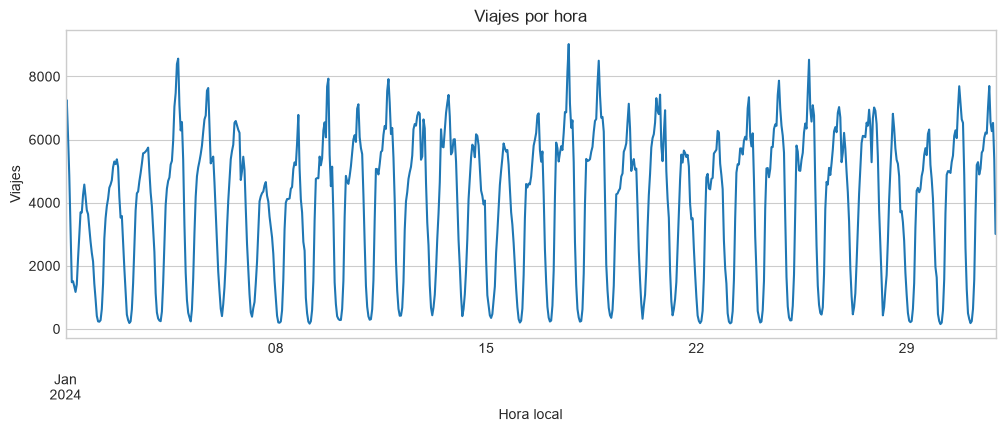

In [18]:
viajes_por_hora = viajes_zonas.set_index("pickup_hora").resample("h").size()
ax = viajes_por_hora.plot(figsize=(12, 4), color="#1f77b4", linewidth=1.5)
ax.set(title="Viajes por hora", xlabel="Hora local", ylabel="Viajes")
plt.show()

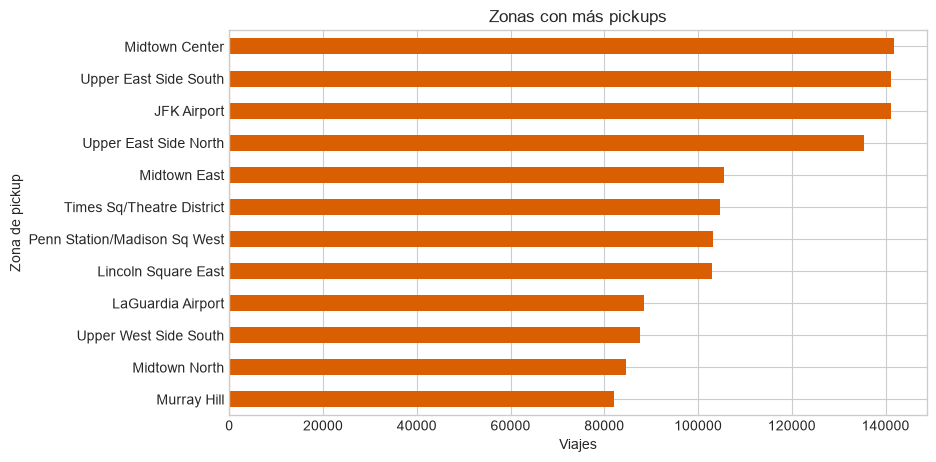

,pickups
pickup_zone,
Midtown Center,141714
Upper East Side South,141237
JFK Airport,141107
Upper East Side North,135303
Midtown East,105440
Times Sq/Theatre District,104590
Penn Station/Madison Sq West,103254
Lincoln Square East,102960
LaGuardia Airport,88556


In [19]:
top_zonas = viajes_zonas["pickup_zone"].value_counts().head(12).sort_values()
ax = top_zonas.plot.barh(figsize=(9, 5), color="#d95f02")
ax.set(title="Zonas con más pickups", xlabel="Viajes", ylabel="Zona de pickup")
plt.show()
display(top_zonas.sort_values(ascending=False).rename("pickups").to_frame())

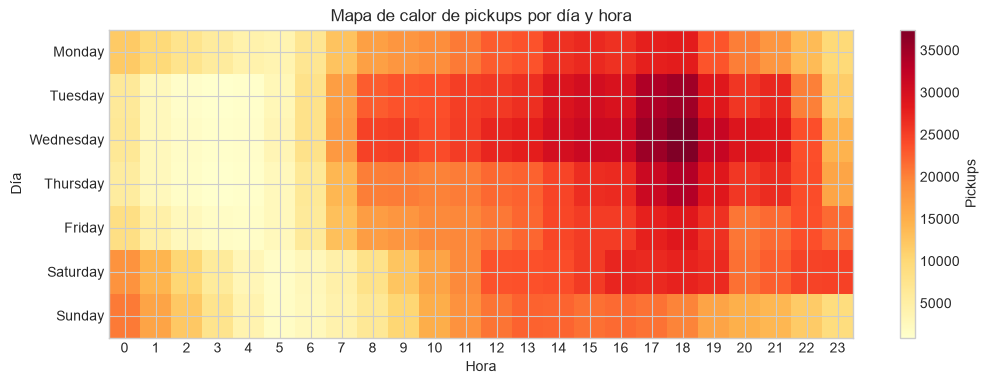

In [20]:
patron = viajes_zonas.assign(
    dia=viajes_zonas["pickup_hora"].dt.day_name(),
    hora_dia=viajes_zonas["pickup_hora"].dt.hour,
).pivot_table(index="dia", columns="hora_dia", values="PULocationID", aggfunc="size", fill_value=0)
orden_dias = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
patron = patron.reindex([d for d in orden_dias if d in patron.index])
fig, ax = plt.subplots(figsize=(12, 4))
imagen = ax.imshow(patron, aspect="auto", cmap="YlOrRd")
ax.set(title="Mapa de calor de pickups por día y hora", xlabel="Hora", ylabel="Día")
ax.set_xticks(range(24), labels=range(24))
ax.set_yticks(range(len(patron.index)), labels=patron.index)
fig.colorbar(imagen, ax=ax, label="Pickups")
plt.show()

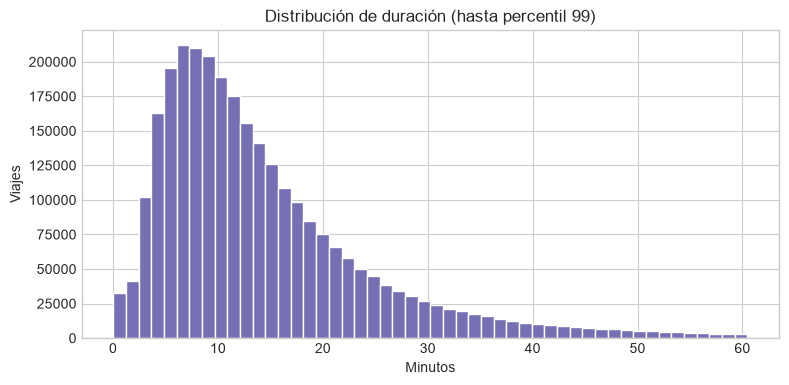

Percentil 99 mostrado: 60.5 minutos


In [21]:
limite_99 = viajes_validos["duracion_min"].quantile(0.99)
ax = viajes_validos.loc[viajes_validos["duracion_min"] <= limite_99, "duracion_min"].plot.hist(
    bins=50, figsize=(9, 4), color="#7570b3", edgecolor="white"
)
ax.set(title="Distribución de duración (hasta percentil 99)", xlabel="Minutos", ylabel="Viajes")
plt.show()
print("Percentil 99 mostrado:", round(limite_99, 1), "minutos")

### 9.1. De zona-hora a una observación por hora

Para comparar la actividad total de taxis con el clima debemos volver de la unidad **zona-hora** a la unidad **hora**. En el ejemplo anterior:

```text
pickups = 20 + 35 + 15 = 70
temperatura = 5 °C
```

Por eso usamos operaciones diferentes:

- `sum` para `pickups`, porque cada zona aporta viajes distintos;
- `first` para temperatura y precipitación, porque cada fila contiene una copia del mismo clima horario.

Sumar la temperatura produciría `5 + 5 + 5 = 15 °C`, un valor sin interpretación física. El uso de `first` requiere comprobar antes que una misma hora no contenga valores climáticos diferentes entre zonas.

Consistencia climática por hora: OK


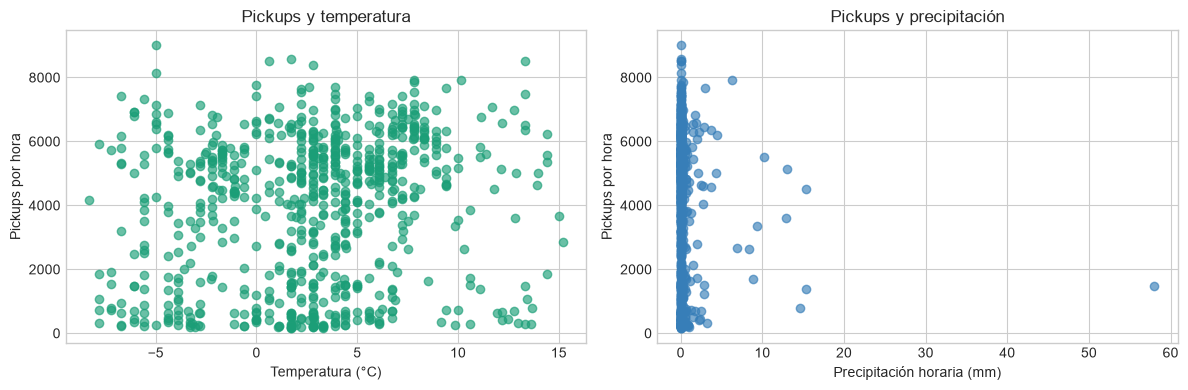

,pickups,temperatura_c,precipitacion_mm
pickups,1.000,0.158,-0.054
temperatura_c,0.158,1.000,0.193
precipitacion_mm,-0.054,0.193,1.000


In [22]:
# Verificamos el supuesto necesario para conservar una sola copia con 'first'.
variables_clima_repetidas = ["temperatura_c", "precipitacion_mm"]
consistencia_clima = (
    zona_hora_clima
    .groupby("pickup_hora")[variables_clima_repetidas]
    .nunique(dropna=False)
)
assert consistencia_clima.le(1).all().all(), (
    "Una misma hora contiene valores climáticos diferentes entre zonas"
)
print("Consistencia climática por hora: OK")

# El clima está repetido por zona; volvemos a una observación por hora.
comparacion_horaria = (
    zona_hora_clima.groupby("pickup_hora", as_index=False)
    .agg(
        pickups=("pickups", "sum"),
        temperatura_c=("temperatura_c", "first"),
        precipitacion_mm=("precipitacion_mm", "first"),
    )
)
assert not comparacion_horaria["pickup_hora"].duplicated().any()
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].scatter(comparacion_horaria["temperatura_c"], comparacion_horaria["pickups"], alpha=0.65, color="#1b9e77")
axes[0].set(xlabel="Temperatura (°C)", ylabel="Pickups por hora", title="Pickups y temperatura")
axes[1].scatter(comparacion_horaria["precipitacion_mm"], comparacion_horaria["pickups"], alpha=0.65, color="#377eb8")
axes[1].set(xlabel="Precipitación horaria (mm)", ylabel="Pickups por hora", title="Pickups y precipitación")
plt.tight_layout()
plt.show()
display(comparacion_horaria[["pickups", "temperatura_c", "precipitacion_mm"]].corr().round(3))

### Pregunta breve

¿Qué ocurriría si sumáramos la temperatura después de haberla replicado por zona?

<details><summary>Ver respuesta orientativa</summary>La misma observación se contabilizaría varias veces y produciría una temperatura sin interpretación física. Los pickups sí se suman porque cada zona aporta viajes diferentes; el clima se conserva una sola vez porque es el mismo valor replicado.</details>

### Ejercicio 3: interpretar sin exagerar

Escribe dos observaciones de los gráficos y una explicación alternativa. Evita frases causales como “la lluvia provoca...”.

**Tu respuesta:**

1. ...
2. ...
3. Explicación alternativa: ...

<details><summary>Ver pauta de solución</summary>Una respuesta sólida identifica dirección, magnitud o franjas horarias, menciona la ventana analizada y reconoce factores de confusión como hora pico, día de semana, aeropuerto, feriados o disponibilidad de taxis. Una correlación horaria no permite atribuir causalidad al clima.</details>

## 10. Exportar el producto fuera del repositorio

Antes de exportar comprobamos la clave, ordenamos el producto y usamos el directorio temporal del sistema. El nombre distingue el modo de clase del mes completo para no declarar una cobertura que no fue procesada.

In [23]:
producto = zona_hora_clima.sort_values(["pickup_hora", "PULocationID"]).copy()
if producto.duplicated(["pickup_hora", "PULocationID"]).any():
    raise ValueError("La clave zona-hora no es única")

alcance = "primera_semana_enero_2024" if MODO_CLASE else "enero_2024"
ruta_producto = Path(tempfile.gettempdir()) / f"zona_hora_{alcance}.parquet"
producto.to_parquet(ruta_producto, index=False)
print("Producto temporal:", ruta_producto)
print("Unidad: zona de origen-hora local | Zona horaria:", ZONA_HORARIA)

Producto temporal: C:\Users\inici\AppData\Local\Temp\zona_hora_enero_2024.parquet
Unidad: zona de origen-hora local | Zona horaria: America/New_York


## 11. Extensión espacial opcional

Esta celda descarga el ZIP del shapefile a un directorio temporal, extrae juntos sus componentes (`.shp`, `.dbf`, `.shx`, `.prj`) y construye un mapa Folium. La extracción explícita evita depender de que el backend geoespacial admita rutas virtuales `zip://`; al finalizar, el directorio temporal se elimina y no deja geometrías en el repositorio. Si `geopandas`, `folium` o `requests` no están instalados, informa exactamente cómo habilitar la sección y el resto del taller sigue siendo utilizable.

In [24]:
try:
    import folium
    import geopandas as gpd
    import requests
    import zipfile
except ModuleNotFoundError as error:
    print(
        f"Sección espacial omitida: falta '{error.name}'. "
        "Descomenta `%pip install -q geopandas folium requests`, reinicia si es necesario y vuelve a ejecutar."
    )
else:
    with tempfile.TemporaryDirectory() as directorio_base:
        ruta_zip = Path(directorio_base) / "taxi_zones.zip"
        respuesta = requests.get(URL_GEOMETRIAS, timeout=60)
        respuesta.raise_for_status()
        ruta_zip.write_bytes(respuesta.content)
        if not zipfile.is_zipfile(ruta_zip):
            raise zipfile.BadZipFile("La descarga de zonas TLC no es un archivo ZIP válido")

        directorio_extraido = Path(directorio_base) / "taxi_zones_extraido"
        directorio_extraido.mkdir()
        with zipfile.ZipFile(ruta_zip) as archivo_zip:
            archivo_zip.extractall(directorio_extraido)

        archivos_shp = sorted(directorio_extraido.rglob("*.shp"))
        if not archivos_shp:
            raise FileNotFoundError("No se encontró un archivo .shp dentro del ZIP de zonas TLC")
        ruta_shp = next((ruta for ruta in archivos_shp if ruta.name == "taxi_zones.shp"), archivos_shp[0])
        geo_zonas = gpd.read_file(ruta_shp).to_crs(epsg=4326)

    pickups_mapa = viajes_zonas["PULocationID"].value_counts().rename("pickups").reset_index()
    geo_zonas["LocationID"] = pd.to_numeric(geo_zonas["LocationID"])
    geo_mapa = geo_zonas.merge(pickups_mapa, left_on="LocationID", right_on="PULocationID", how="left", validate="one_to_one")
    geo_mapa["pickups"] = geo_mapa["pickups"].fillna(0)
    min_x, min_y, max_x, max_y = geo_mapa.total_bounds
    centro = [(min_y + max_y) / 2, (min_x + max_x) / 2]
    mapa = folium.Map(location=centro, zoom_start=10, tiles="CartoDB positron")
    folium.Choropleth(
        geo_data=geo_mapa, data=geo_mapa, columns=["LocationID", "pickups"],
        key_on="feature.properties.LocationID", fill_color="YlOrRd",
        fill_opacity=0.7, line_opacity=0.3, legend_name="Pickups",
    ).add_to(mapa)
    folium.GeoJson(
        geo_mapa, style_function=lambda _: {"fillOpacity": 0, "weight": 0},
        tooltip=folium.GeoJsonTooltip(fields=["zone", "borough", "pickups"], aliases=["Zona", "Borough", "Pickups"]),
    ).add_to(mapa)
    display(mapa)

Sección espacial omitida: falta 'folium'. Descomenta `%pip install -q geopandas folium requests`, reinicia si es necesario y vuelve a ejecutar.


## 12. Conclusiones y límites

**Qué construimos**

- un proceso reproducible para enero de 2024, escalable de una semana al mes;
- una auditoría que hace visibles los criterios de exclusión;
- una tabla zona-hora enriquecida con clima mediante cardinalidad comprobada;
- visualizaciones temporales, espaciales y de asociación exploratoria.

**Límites que deben acompañar cualquier conclusión**

- Los registros son **viajes reportados de Yellow Taxi**, no demanda total, viajes no atendidos ni toda la movilidad de Nueva York.
- Una sola estación, `USW00094728`, no representa toda la variación meteorológica espacial de la ciudad.
- La cobertura y frecuencia de GHCNh pueden variar; resumir precipitación subhoraria exige revisar la documentación de medición.
- Las reglas de calidad y sus umbrales afectan los resultados y deben justificarse.
- La asociación entre pickups y clima está confundida por hora, día, localización, oferta, eventos y otros factores. **Correlación no implica causalidad.**
- `MODO_CLASE=True` describe solo la primera semana; para conclusiones mensuales se debe ejecutar el mes completo y evaluar estabilidad.

**Cierre:** ¿qué dato adicional pedirías para distinguir mejor demanda, oferta y viajes efectivamente realizados?

## Trabajo práctico: exploración de dos variables

**Estudiante:** juanpablopillack@gmail.com
**Modalidad:** individual · **Periodo:** enero de 2024 completo, hora de Nueva York (`America/New_York`)

**Antes de ver ningún resultado, dejo anotado qué par elegí:** trabajo con **PC-01 — `pickups` × `temperatura_c`**, usando la **vista H (horaria)**, es decir, una fila por cada hora de enero. Me comprometo a mantener este par y esta vista hasta el final, sin cambiarlos aunque el resultado no sea el que esperaba.

Esta sección parte de la misma copia del notebook base de arriba. Para trabajar sobre el mes completo cambié `MODO_CLASE` a `False` en la celda de configuración (sección 1), y corrí todo el notebook base de punta a punta antes de llegar acá.

### 5. Contrato del análisis

*(lo completo antes de calcular nada, como pide la sección 5 de la consigna — así dejo el plan fijado antes de ver ningún resultado)*

| Campo | Respuesta del estudiante |
|---|---|
| **Código y par elegido** | PC-01 — `pickups` (columna 1) y `temperatura_c` (columna 2) |
| **Pregunta exploratoria** | ¿Cómo varían los pickups totales por hora junto con la temperatura del aire registrada, durante enero de 2024, en la ciudad de Nueva York (hora local)? |
| **Significado de la primera columna** | `pickups`: cantidad de viajes de Yellow Taxi que arrancaron (*pickup*) durante esa hora, sumando todas las zonas de origen activas en esa hora. Es un conteo de viajes reportados y válidos, no una medida de demanda total. |
| **Significado de la segunda columna** | `temperatura_c`: temperatura del aire en grados Celsius, medida por la estación meteorológica NOAA `USW00094728` (Central Park, NY) y resumida a un valor por hora. Es un único dato de una sola estación, no algo que cambie por zona. |
| **Tipo semántico de cada columna** | `pickups`: numérica discreta (conteo, entero ≥ 0). `temperatura_c`: numérica continua. |
| **Unidad analítica y vista** | Vista **H (horaria)**: cada fila representa una hora de enero de 2024. |
| **Periodo y zona horaria** | `[2024-01-01T00:00, 2024-02-01T00:00)`, hora local `America/New_York` (intervalo cerrado a la izquierda, abierto a la derecha). |
| **Población registrada** | Horas de enero de 2024 en las que al menos una zona registró al menos un pickup válido de Yellow Taxi (las horas sin ningún pickup en ninguna zona no generan fila en `producto`, y por lo tanto tampoco en `por_hora`). |
| **Denominador o tamaño válido** | Para `pickups`: las 744 filas de `por_hora` (no hay faltantes, es una suma). Para `temperatura_c`: solo las filas con valor NOAA no nulo (se cuenta en la sección 6.3). |
| **Afirmaciones que los datos no permiten** | (1) No permiten estimar la demanda total de viajes, solo los viajes de Yellow Taxi que efectivamente se hicieron, se reportaron y pasaron los filtros de calidad. (2) No permiten decir que la temperatura *cause* cambios en los pickups: cualquier asociación observada puede estar mezclada con la hora del día, el día de la semana, feriados o la disponibilidad de taxis (ver sección 8.4). (3) No permiten generalizar a otros meses o años sin repetir el análisis sobre esos periodos. |

### Construcción y validación de la vista H

Antes de comparar pickups con temperatura, tengo que pasar de la unidad **zona-hora** (que ya tiene `producto`) a la unidad **hora**: sumo los pickups de todas las zonas activas de cada hora, y me quedo con un solo valor de clima por hora (con `first`), después de comprobar que ese valor realmente es el mismo para todas las zonas de esa hora.

In [25]:
from scipy import stats

# Vista H: una fila por hora de enero. Antes de usar "first" compruebo que
# el clima efectivamente sea el mismo para todas las zonas activas de cada
# hora (si no lo fuera, "first" no sería una simplificación válida).
variables_clima_h = ["temperatura_c", "humedad_relativa", "viento", "visibilidad"]
consistencia_h = producto.groupby("pickup_hora")[variables_clima_h].nunique(dropna=False)
assert consistencia_h.le(1).all().all(), "El clima no es constante entre zonas de la misma hora"
print("Consistencia climática por hora: OK")

por_hora = producto.groupby("pickup_hora", as_index=False).agg(
    pickups=("pickups", "sum"),
    temperatura_c=("temperatura_c", "first"),
    humedad_relativa=("humedad_relativa", "first"),
    viento=("viento", "first"),
    visibilidad=("visibilidad", "first"),
)
assert not por_hora["pickup_hora"].duplicated().any(), "pickup_hora debería ser único en por_hora"
print("Filas en por_hora:", len(por_hora))
display(por_hora.head())

Consistencia climática por hora: OK
Filas en por_hora: 744


,pickup_hora,pickups,temperatura_c,humedad_relativa,viento,visibilidad
0,2024-01-01 00:00:00-05:00,6513,5.6,55.0,3.1,16.093
1,2024-01-01 01:00:00-05:00,7249,5.6,58.0,2.1,16.093
2,2024-01-01 02:00:00-05:00,6111,5.0,60.0,0.0,16.093
3,2024-01-01 03:00:00-05:00,4857,5.0,62.0,1.5,16.093
4,2024-01-01 04:00:00-05:00,3128,4.4,68.0,0.0,16.093


In [26]:
inicio_local = INICIO_MES.tz_localize(ZONA_HORARIA)
fin_local = FIN_ANALISIS.tz_localize(ZONA_HORARIA)
horas_esperadas = pd.date_range(inicio_local, fin_local, freq="h", inclusive="left")

huecos = horas_esperadas.difference(por_hora["pickup_hora"])
print("Horas esperadas en enero:", len(horas_esperadas))
print("Filas en por_hora:", len(por_hora))
print("Horas esperadas sin fila en por_hora:", len(huecos))

Horas esperadas en enero: 744
Filas en por_hora: 744
Horas esperadas sin fila en por_hora: 0


### 6. Exploración individual de cada columna

Primero miro `pickups` sola, después `temperatura_c` sola. Recién en la sección 8 las cruzo.

#### 6.1. `pickups` — comprensión y cobertura

- **Qué representa:** cantidad de viajes de Yellow Taxi que arrancaron en esa hora, sumando
  todas las zonas de origen activas esa hora (la agregación es una **suma**, ver la
  construcción de la vista H más arriba).
- **Unidad:** viajes por hora (un conteo).
- **Tipo de dato físico:** entero. **Tipo semántico:** numérica discreta (es un conteo).
- **Agregación aplicada:** `sum` sobre `pickups` de `producto`, agrupando por `pickup_hora`.

In [27]:
pk = por_hora["pickups"]
print("Filas totales:", len(por_hora))
print("Tipo de dato físico:", pk.dtype)
print("Faltantes:", pk.isna().sum())
print("Ceros:", int((pk == 0).sum()), f"({100 * (pk == 0).mean():.2f}%)")
print("Mínimo:", pk.min(), "| Máximo:", pk.max())

Filas totales: 744
Tipo de dato físico: int64
Faltantes: 0
Ceros: 0 (0.00%)
Mínimo: 152 | Máximo: 9027


#### 6.2. `pickups` — distribución

Para elegir el ancho de las barras del histograma no tiré un número al azar: usé la regla de Freedman-Diaconis (`bins="fd"` en matplotlib), que calcula el ancho a partir del IQR y de la cantidad de datos.

Q1: 1592.25 | Q3: 5719.25 | IQR: 4127.0
Desviación estándar: 2275.77


,pickups
count,744.000000
mean,3932.931452
std,2275.767808
min,152.000000
25%,1592.250000
50%,4519.000000
75%,5719.250000
max,9027.000000


C:\Users\inici\AppData\Local\Temp\ipykernel_30152\920500263.py:11: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axes[1].boxplot(pk, vert=True)


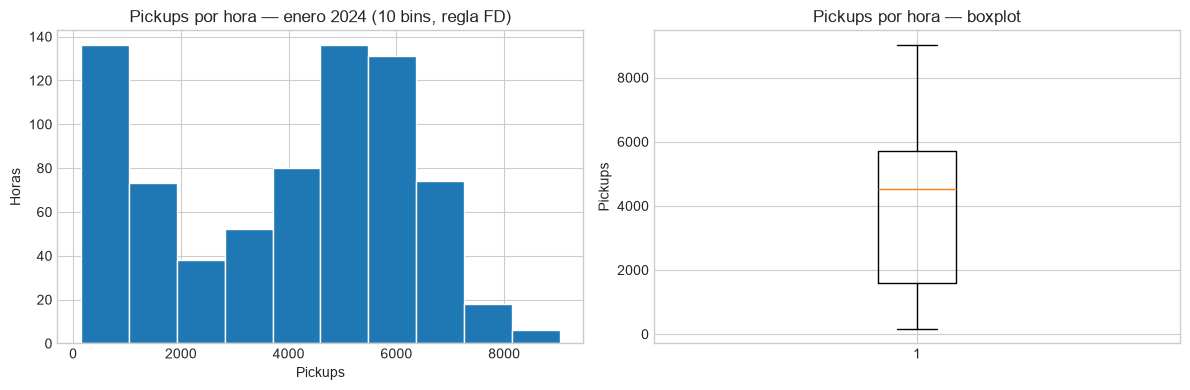

Ancho de bin (Freedman-Diaconis): 887.5


In [28]:
resumen_pk = pk.describe(percentiles=[0.25, 0.5, 0.75])
q1_pk, q3_pk = pk.quantile(0.25), pk.quantile(0.75)
iqr_pk = q3_pk - q1_pk
print("Q1:", q1_pk, "| Q3:", q3_pk, "| IQR:", iqr_pk)
print("Desviación estándar:", round(pk.std(), 2))
display(resumen_pk.to_frame())

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
counts, edges, _ = axes[0].hist(pk, bins="fd", color="#1f77b4", edgecolor="white")
axes[0].set(title=f"Pickups por hora — enero 2024 ({len(edges)-1} bins, regla FD)", xlabel="Pickups", ylabel="Horas")
axes[1].boxplot(pk, vert=True)
axes[1].set(title="Pickups por hora — boxplot", ylabel="Pickups")
plt.tight_layout()
plt.show()
print("Ancho de bin (Freedman-Diaconis):", round(edges[1] - edges[0], 1))

**Lo que muestra el histograma y el boxplot:** los pickups por hora van de un mínimo de 152 a un máximo de 9.027, con una media de 3.932,9 y una mediana de 4.519 (la media queda un poco por debajo de la mediana, señal de que hay más horas de baja actividad "tirando" el promedio hacia abajo). El rango intercuartílico (IQR) es de 4.127 (entre Q1 = 1.592,25 y Q3 = 5.719,25), y la desviación estándar es 2.275,8. No hay valores faltantes ni horas con cero pickups: siempre hubo algo de actividad, aunque en la madrugada baje mucho.

El histograma (10 bins, ancho ≈ 888 pickups, calculado con la regla de Freedman-Diaconis) muestra una forma con dos zonas de concentración: una en valores bajos (las horas de madrugada, con poca actividad) y otra más dispersa hacia valores medios-altos (el resto del día). El boxplot no marca ningún punto como atípico con esta escala.

#### 6.3. `temperatura_c` — comprensión y cobertura

- **Qué representa:** temperatura del aire en grados Celsius, medida por la estación NOAA
  `USW00094728` y resumida a un solo valor por hora. La agregación es **first** (me quedo con
  el primer valor), pero recién después de comprobar que ese valor es igual para todas las
  zonas activas de la hora — ver la construcción de la vista H.
- **Unidad:** grados Celsius (°C).
- **Tipo de dato físico:** decimal. **Tipo semántico:** numérica continua.

In [29]:
tc = por_hora["temperatura_c"]
print("Filas totales:", len(por_hora))
print("Tipo de dato físico:", tc.dtype)
n_faltantes_tc = tc.isna().sum()
print("Faltantes:", n_faltantes_tc, f"({100 * n_faltantes_tc / len(tc):.2f}%)")
print("Mínimo:", tc.min(), "| Máximo:", tc.max())
print(
    "¿Algún valor fuera de un rango físicamente plausible para NYC en enero (-30°C a 40°C)?",
    int(((tc < -30) | (tc > 40)).sum()),
)

Filas totales: 744
Tipo de dato físico: float64
Faltantes: 1 (0.13%)
Mínimo: -8.3 | Máximo: 15.200000000000001
¿Algún valor fuera de un rango físicamente plausible para NYC en enero (-30°C a 40°C)? 0


#### 6.4. `temperatura_c` — distribución

Para el histograma de temperatura también usé la regla de Freedman-Diaconis, aplicada solo sobre los valores no faltantes.

Q1: -0.6 | Q3: 6.1 | IQR: 6.7
Desviación estándar: 4.76


,temperatura_c
count,743.000000
mean,2.735884
std,4.762700
min,-8.300000
25%,-0.600000
50%,2.800000
75%,6.100000
max,15.200000


C:\Users\inici\AppData\Local\Temp\ipykernel_30152\3415729412.py:11: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axes[1].boxplot(tc.dropna(), vert=True)


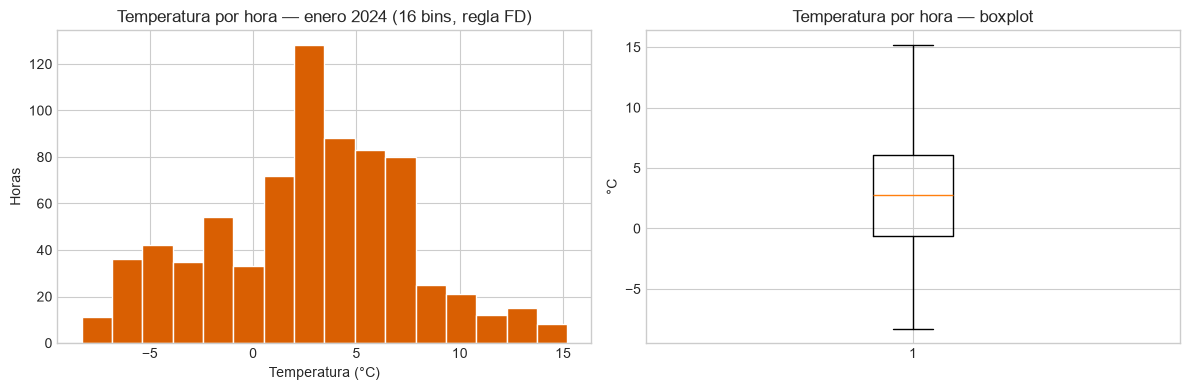

Ancho de bin (Freedman-Diaconis): 1.469


In [30]:
resumen_tc = tc.describe(percentiles=[0.25, 0.5, 0.75])
q1_tc, q3_tc = tc.quantile(0.25), tc.quantile(0.75)
iqr_tc = q3_tc - q1_tc
print("Q1:", q1_tc, "| Q3:", q3_tc, "| IQR:", round(iqr_tc, 2))
print("Desviación estándar:", round(tc.std(), 2))
display(resumen_tc.to_frame())

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
counts, edges, _ = axes[0].hist(tc.dropna(), bins="fd", color="#d95f02", edgecolor="white")
axes[0].set(title=f"Temperatura por hora — enero 2024 ({len(edges)-1} bins, regla FD)", xlabel="Temperatura (°C)", ylabel="Horas")
axes[1].boxplot(tc.dropna(), vert=True)
axes[1].set(title="Temperatura por hora — boxplot", ylabel="°C")
plt.tight_layout()
plt.show()
print("Ancho de bin (Freedman-Diaconis):", round(edges[1] - edges[0], 3))

**Lo que muestra el histograma y el boxplot:** la temperatura de enero va de -8,3°C a 15,2°C, con una media de 2,74°C y una mediana de 2,8°C (muy parecidas, así que la distribución no tiene una asimetría fuerte). El IQR es de 6,7°C (entre Q1 = -0,6°C y Q3 = 6,1°C), y la desviación estándar es 4,76°C. Falta el dato de 1 hora sobre 744 (0,13%), que queda como `NaN` y no se convierte en cero. Ningún valor está fuera de un rango físicamente plausible para Nueva York en enero, así que no hay señales de error de carga.

El histograma (16 bins, ancho ≈ 1,47°C, regla de Freedman-Diaconis) muestra una forma razonablemente simétrica, centrada un poco por encima de los 0°C, consistente con un enero de invierno templado-frío en Nueva York, sin una cola muy marcada hacia ningún lado.

### 7. Casos potencialmente anómalos

**Regla que uso:** la regla de Tukey. Marca como "candidato a revisar" cualquier valor que
quede fuera del rango `[Q1 - 1.5*IQR, Q3 + 1.5*IQR]`, calculado sobre `por_hora` (enero
completo). Que algo quede marcado no significa que esté mal, solo indica que conviene mirarlo
con más atención.

#### 7.1. Candidatos en `pickups`

In [31]:
limite_inf_pk = q1_pk - 1.5 * iqr_pk
limite_sup_pk = q3_pk + 1.5 * iqr_pk
print(f"Rango de Tukey para pickups: [{limite_inf_pk:.2f}, {limite_sup_pk:.2f}]")
candidatos_pk = por_hora.loc[(pk < limite_inf_pk) | (pk > limite_sup_pk)]
print("Candidatos señalados:", len(candidatos_pk))
display(candidatos_pk[["pickup_hora", "pickups"]])

Rango de Tukey para pickups: [-4598.25, 11909.75]
Candidatos señalados: 0


,pickup_hora,pickups


**Resultado (enero de 2024 completo):** con la regla de Tukey, `pickups` no tiene ningún caso
señalado — las 744 horas del mes quedan dentro de `[-4.598,25, 11.909,75]` (el límite inferior
da negativo porque la fórmula no tiene un piso en cero, pero como `pickups` nunca puede ser
negativo, en la práctica eso no descarta ningún valor real). Tiene sentido que dé así: acá estoy
sumando los pickups de todas las zonas activas de NYC en cada hora, entonces la serie ya viene
bastante "suavizada" por esa suma. Además el IQR (4.127, sección 6.2) es lo bastante amplio como
para cubrir tanto las horas de madrugada, con poca actividad, como las horas pico, sin que
ninguna quede afuera de los límites de Tukey.

Esto no quiere decir que no haya horas con actividad muy distinta entre sí — la sección 6.2 ya
muestra que hay bastante diferencia entre el mínimo (152) y el máximo (9.027) observados. Lo que
pasa es que, mirado hora por hora para todo NYC junto, ninguna se aleja lo suficiente del resto
como para que Tukey la marque. Si en vez de sumar todo NYC mirara zona por zona (vista ZH) o
franjas horarias más chicas, es probable que sí aparezcan candidatos que acá quedan "tapados"
por la agregación. Lo dejo anotado como algo para revisar más adelante (sección 11).

**Si en una re-ejecución futura aparecieran candidatos** (por ejemplo, si TLC actualiza la
fuente), las explicaciones más probables serían: horas de aeropuertos o eventos puntuales que
suben el total, condiciones climáticas extremas que lo bajan, o algún problema de agregación
— esto último ya lo puedo descartar, porque `pickups_zona_hora` quedó validado como clave única
antes de llegar a `producto`.

**Decisión:** no tengo ningún caso que conservar, excluir o corregir en `pickups` para este
periodo y esta vista. Documento igual el resultado (0 candidatos), porque es parte de lo que
pide la consigna.

#### 7.2. Candidatos en `temperatura_c`

In [32]:
limite_inf_tc = q1_tc - 1.5 * iqr_tc
limite_sup_tc = q3_tc + 1.5 * iqr_tc
print(f"Rango de Tukey para temperatura_c: [{limite_inf_tc:.2f}, {limite_sup_tc:.2f}]")
candidatos_tc = por_hora.loc[tc.notna() & ((tc < limite_inf_tc) | (tc > limite_sup_tc))]
print("Candidatos señalados:", len(candidatos_tc))
display(candidatos_tc[["pickup_hora", "temperatura_c"]])

Rango de Tukey para temperatura_c: [-10.65, 16.15]
Candidatos señalados: 0


,pickup_hora,temperatura_c


**Resultado:** en `temperatura_c` tampoco aparece ningún caso señalado (0 de 743 horas con dato
válido, sobre un rango de Tukey de `[-10,65°C, 16,15°C]`). El rango de temperatura de enero
(mínimo y máximo, sección 6.4) queda dentro de esos límites, así que no hubo olas de frío o
calor que se despeguen tanto del resto como para que la regla las marque.

**Decisión:** no hay casos para conservar, excluir o corregir en `temperatura_c`. Tiene sentido:
la temperatura en enero en Nueva York cambia de a poco (entran y salen frentes fríos o cálidos
que duran horas o días), no pega saltos bruscos de una hora a la siguiente.

### 8. Relación entre las columnas

#### 8.1. `pickups` vs. `temperatura_c` — dos variables numéricas

Horas con las dos variables presentes: 743
Pearson r = 0.158 (p = 1.46e-05)
Spearman rho = 0.184 (p = 4.25e-07)
No hubo candidatos señalados en 7.1 ni 7.2: no hay nada que excluir, los coeficientes no cambian.


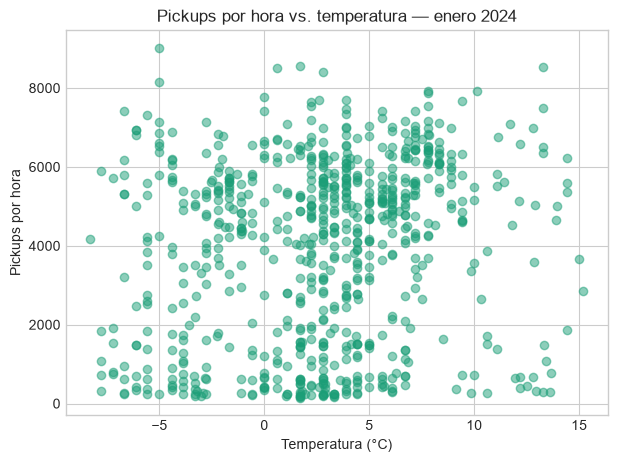

In [33]:
ambos = por_hora.dropna(subset=["pickups", "temperatura_c"]).copy()
print("Horas con las dos variables presentes:", len(ambos))

pearson_r, pearson_p = stats.pearsonr(ambos["pickups"], ambos["temperatura_c"])
spearman_r, spearman_p = stats.spearmanr(ambos["pickups"], ambos["temperatura_c"])
print(f"Pearson r = {pearson_r:.3f} (p = {pearson_p:.2e})")
print(f"Spearman rho = {spearman_r:.3f} (p = {spearman_p:.2e})")

if len(candidatos_pk) or len(candidatos_tc):
    sin_candidatos = ambos.loc[
        ~ambos["pickup_hora"].isin(candidatos_pk["pickup_hora"])
        & ~ambos["pickup_hora"].isin(candidatos_tc["pickup_hora"])
    ]
    pr2, _ = stats.pearsonr(sin_candidatos["pickups"], sin_candidatos["temperatura_c"])
    sr2, _ = stats.spearmanr(sin_candidatos["pickups"], sin_candidatos["temperatura_c"])
    print(f"Sin los casos señalados en 7.1/7.2 -> Pearson r = {pr2:.3f}, Spearman rho = {sr2:.3f}, n = {len(sin_candidatos)}")
else:
    print("No hubo candidatos señalados en 7.1 ni 7.2: no hay nada que excluir, los coeficientes no cambian.")

fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(ambos["temperatura_c"], ambos["pickups"], alpha=0.5, color="#1b9e77")
ax.set(title="Pickups por hora vs. temperatura — enero 2024", xlabel="Temperatura (°C)", ylabel="Pickups por hora")
plt.show()

**Resultado (enero de 2024 completo, 743 horas con las dos variables presentes):** Pearson
r = **0,158** (p ≈ 0,0000146) y Spearman rho = **0,184** (p ≈ 0,0000004). Los dos son positivos,
bajos, y estadísticamente significativos (el p-valor es muy chico, así que es poco probable que
esta asociación sea puro ruido) — pero "significativo" no es lo mismo que "fuerte": la relación
sigue siendo débil en magnitud. Como en las secciones 7.1 y 7.2 no señalé ningún candidato, no
hay nada que excluir y los coeficientes no cambian.

Esto coincide con lo que se ve en el gráfico de dispersión: hay una leve tendencia a que haya
más pickups en las horas más cálidas, pero los puntos están muy dispersos, lejos de formar una
línea clara. Como Pearson y Spearman dan valores parecidos, no parece que haya una relación no
lineal más fuerte que Pearson esté "escondiendo".

In [34]:
autocorr_pk = por_hora["pickups"].autocorr(lag=1)
autocorr_tc = por_hora["temperatura_c"].autocorr(lag=1)
print(f"Autocorrelación lag-1 de pickups (hora vs. hora anterior): {autocorr_pk:.3f}")
print(f"Autocorrelación lag-1 de temperatura_c (hora vs. hora anterior): {autocorr_tc:.3f}")

Autocorrelación lag-1 de pickups (hora vs. hora anterior): 0.937
Autocorrelación lag-1 de temperatura_c (hora vs. hora anterior): 0.992


#### 8.4. Dependencia y explicaciones alternativas

Las horas de `por_hora` no son observaciones independientes entre sí. Lo puedo mostrar con un
número concreto: la autocorrelación lag-1 (qué tan parecida es una hora a la hora inmediatamente
anterior) es de **0,937** para `pickups` y de **0,992** para `temperatura_c` — valores muy
cercanos a 1, que confirman que ambas series cambian de forma gradual, no al azar de una hora a
la siguiente. Además, las dos variables comparten ciclos diarios (hora pico vs. madrugada) y
semanales (día de semana vs. fin de semana). Entonces, aunque `por_hora` tenga 744 filas, el
número de observaciones realmente "independientes" para interpretar el coeficiente de
correlación es bastante menor a 744.

Por eso, cualquier asociación entre `pickups` y `temperatura_c` puede estar confundida con:

- **el ciclo diario** (la temperatura más baja suele darse de madrugada, que también es cuando
  hay menos pickups, pero por razones que no tienen nada que ver con el clima);
- **el día de la semana** (los patrones de viaje cambian entre semana y fin de semana, y eso
  puede coincidir por casualidad con rachas de frío o calor de ese mes);
- **la disponibilidad de taxis** o **algún evento puntual** que estas dos columnas no capturan.

La variable de clima viene de una sola estación (sección 2 de la consigna). Reducir todo a una
fila por hora ya evita contar el mismo dato de clima varias veces por zona, pero no borra la
dependencia entre horas consecutivas que acabo de mostrar. En la siguiente sección reviso
justamente si el patrón que veo se sostiene aunque controle, aunque sea de forma parcial, por el
ciclo semanal.

### 9. Análisis de sensibilidad

**Decisión que tomé antes de ver el resultado:** separar la relación `pickups` vs.
`temperatura_c` entre **días laborables y fines de semana**, para ver si la asociación que
aparece en el conjunto completo se mantiene, se debilita o cambia de signo dentro de cada
grupo. Es una forma simple de chequear el tipo de confusión temporal que mencioné en el
punto 8.4.

Días laborables (n=551): Pearson r = 0.197, Spearman rho = 0.215
Fin de semana   (n=192): Pearson r = 0.051, Spearman rho = 0.101


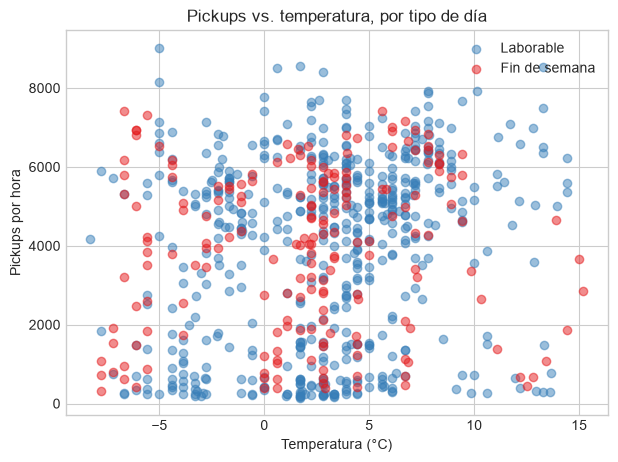

In [35]:
ambos["dia_semana"] = ambos["pickup_hora"].dt.day_name()
ambos["es_fin_de_semana"] = ambos["pickup_hora"].dt.dayofweek.isin([5, 6])

laborable = ambos.loc[~ambos["es_fin_de_semana"]]
fin_de_semana = ambos.loc[ambos["es_fin_de_semana"]]

pr_lab, _ = stats.pearsonr(laborable["pickups"], laborable["temperatura_c"])
sr_lab, _ = stats.spearmanr(laborable["pickups"], laborable["temperatura_c"])
pr_fin, _ = stats.pearsonr(fin_de_semana["pickups"], fin_de_semana["temperatura_c"])
sr_fin, _ = stats.spearmanr(fin_de_semana["pickups"], fin_de_semana["temperatura_c"])

print(f"Días laborables (n={len(laborable)}): Pearson r = {pr_lab:.3f}, Spearman rho = {sr_lab:.3f}")
print(f"Fin de semana   (n={len(fin_de_semana)}): Pearson r = {pr_fin:.3f}, Spearman rho = {sr_fin:.3f}")

fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(laborable["temperatura_c"], laborable["pickups"], alpha=0.5, label="Laborable", color="#377eb8")
ax.scatter(fin_de_semana["temperatura_c"], fin_de_semana["pickups"], alpha=0.5, label="Fin de semana", color="#e41a1c")
ax.set(title="Pickups vs. temperatura, por tipo de día", xlabel="Temperatura (°C)", ylabel="Pickups por hora")
ax.legend()
plt.show()

**Resultado:** en días laborables (n = 551 horas) la asociación es un poco más marcada
(Pearson r = 0,197, Spearman rho = 0,215) que en fines de semana (n = 192 horas: Pearson
r = 0,051, Spearman rho = 0,101). Pero en los dos grupos el signo sigue siendo positivo, igual
que en el conjunto completo (rho = 0,184), y ninguno se invierte. No hay señal de efecto Simpson
(una relación que cambia de signo al separar los datos): la asociación positiva y débil se
sostiene en ambos grupos, aunque es notoriamente más débil los fines de semana — vale la pena
aclarar esto junto con el hallazgo principal.

**¿Cómo leo este resultado?** Si los coeficientes por grupo tienen el mismo signo y una
magnitud parecida a la del conjunto completo, quiere decir que la asociación no depende de
mezclar días laborables con fines de semana — es un resultado más sólido. Acá los coeficientes
cambian bastante de magnitud (más del doble entre laborables y fin de semana), aunque no de
signo, así que el patrón global no representa exactamente igual a los dos grupos: conviene
comunicar el hallazgo aclarando que es más marcado durante la semana que los fines de semana.

### 10. Hallazgos finales

#### Hallazgo 1 — sobre `pickups`

- **Contrato:** todas las horas de enero de 2024 con al menos un pickup válido de Yellow Taxi
  en alguna zona de NYC, hora local `America/New_York` (vista H).
- **Observación:** `por_hora` tiene 744 filas, una por cada hora del mes, sin huecos. Los
  pickups por hora van de un mínimo de 152 a un máximo de 9.027, con una mediana de 4.519 y un
  IQR de 4.127 (sección 6.2). Con la regla de Tukey no aparece ningún caso señalado (sección
  7.1): el rango intercuartílico ya es lo bastante amplio como para cubrir tanto las horas de
  menor actividad como los picos.
- **Cobertura:** sin faltantes, porque es una suma agregada; las 744 horas esperadas de enero
  tienen su fila en `por_hora`.
- **Interpretación:** los pickups por hora varían mucho a lo largo del día (de 152 en el mínimo
  a 9.027 en el máximo), pero dentro de un rango que, medido con Tukey sobre el mes completo, no
  deja valores sueltos aislados: la variación es más bien suave, coherente con ciclos diarios y
  no con eventos puntuales extremos.
- **Explicación alternativa:** que Tukey no marque nada puede deberse a que la vista horaria
  (sumando todas las zonas de NYC) diluye anomalías que sí podrían verse zona por zona
  (vista ZH) o en franjas horarias más chicas.
- **Límite:** esta columna no mide demanda total ni oferta de taxis disponible; solo cuenta
  viajes que efectivamente se hicieron, se reportaron y pasaron los filtros de calidad.
- **Siguiente comprobación posible:** desagregar por zona/borough (vista ZH) o aplicar Tukey
  dentro de cada franja horaria, para ver si aparecen candidatos que la vista agregada no deja
  ver.

#### Hallazgo 2 — sobre `temperatura_c`

- **Contrato:** horas de enero de 2024 con observación meteorológica válida de la estación NOAA
  `USW00094728`, `America/New_York` (vista H).
- **Observación:** de las 744 horas de `por_hora`, 743 tienen temperatura válida (falta 1 hora,
  un 0,13%, que queda como `NaN`). La temperatura va de -8,3°C a 15,2°C, con mediana de 2,8°C e
  IQR de 6,7°C (sección 6.4). Tukey tampoco marca nada acá (sección 7.2): 0 de 743 horas quedan
  fuera de rango.
- **Cobertura:** informo la cantidad y el porcentaje de horas sin dato NOAA (sección 6.3); esas
  horas quedan como faltantes (`NaN`), no como cero.
- **Interpretación:** enero de 2024 tiene la variabilidad térmica típica de un mes de invierno
  en Nueva York (de bastante frío a templado), pero sin saltos bruscos de una hora a otra que
  Tukey identifique como atípicos.
- **Explicación alternativa:** que no aparezcan candidatos concuerda con que la temperatura
  cambia de forma gradual (autocorrelación lag-1 de 0,992, sección 8.4: entran y salen frentes
  fríos o cálidos que duran horas o días), no en picos aislados de una sola hora.
- **Límite:** el dato viene de una única estación meteorológica; no representa cómo varía el
  clima dentro de la ciudad según la zona.
- **Siguiente comprobación posible:** comparar con otra estación cercana o con datos de
  reanálisis climático, para confirmar que no hay valores anómalos que esta estación sola no
  deja ver.

#### Hallazgo 3 — sobre la relación entre ambas

- **Contrato:** horas de enero de 2024 con pickups y temperatura válidos al mismo tiempo
  (vista H, 743 de 744 horas), sección 8.1.
- **Observación:** el diagrama de dispersión muestra una nube de puntos dispersa con una leve
  tendencia ascendente. Los coeficientes son Pearson r = 0,158 (p ≈ 0,0000146) y Spearman
  rho = 0,184 (p ≈ 0,0000004), iguales con y sin los casos de las secciones 7.1/7.2, porque no
  hubo ninguno que excluir. Al separar por día laborable/fin de semana (sección 9), la
  asociación es más marcada en días laborables (r = 0,197, rho = 0,215, n = 551 horas) que en
  fines de semana (r = 0,051, rho = 0,101, n = 192 horas), pero sin cambiar de signo en ningún
  grupo.
- **Cobertura:** 743 de 744 horas de `por_hora` tienen las dos columnas válidas al mismo tiempo.
- **Interpretación:** se observa una **asociación positiva pero débil** entre pickups y
  temperatura por hora en enero de 2024: en promedio, las horas más cálidas tienden a tener un
  poco más de pickups, pero la relación está lejos de ser fuerte, y es todavía más débil los
  fines de semana.
- **Explicación alternativa:** esta asociación puede estar impulsada, total o parcialmente, por
  el ciclo diario o semanal que comparten las dos variables (autocorrelación lag-1 de 0,937 para
  pickups y 0,992 para temperatura, sección 8.4) — por ejemplo, las horas más cálidas del día
  suelen coincidir con las horas de más actividad. La diferencia entre días laborables y fines
  de semana va en esa línea, aunque el análisis de sensibilidad no encontró un cambio de signo
  tipo efecto Simpson.
- **Límite:** el estudio es observacional; un r/rho de esta magnitud no alcanza para decir que
  la temperatura *causa* cambios en los pickups, ni descarta que otros factores compartidos
  (hora pico, día de semana, eventos, disponibilidad de taxis) expliquen parte o todo el patrón.
- **Siguiente comprobación posible:** un modelo que controle explícitamente por hora del día y
  día de la semana (por ejemplo, una regresión con esas variables incluidas), para separar mejor
  el rol de la temperatura del rol de los ciclos de calendario.

### 11. Límites y próximos pasos

- Los registros de TLC son viajes de Yellow Taxi que efectivamente se hicieron, se reportaron y
  pasaron los filtros de calidad del notebook base; no representan la demanda total de viajes ni
  las solicitudes que no fueron atendidas.
- La variable de clima viene de una sola estación meteorológica y se repite en todas las zonas
  activas de una misma hora. Ya corregí la repetición por zona (vista H), pero la dependencia
  entre horas consecutivas sigue ahí (autocorrelación lag-1 de 0,937 en pickups y 0,992 en
  temperatura) y no la modelé de forma explícita.
- Este es un análisis exploratorio y descriptivo: muestra una asociación entre `pickups` y
  `temperatura_c`, no prueba una relación de causa y efecto.
- **Como próximo paso podría:** repetir el análisis desagregando por zona/borough (vista ZH);
  extender el periodo a varios meses para ver si el patrón se mantiene (la actividad EXTRA de la
  consigna); o agregar controles explícitos por hora del día y día de la semana en un modelo
  estadístico.